<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/RNN_%26_mental_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [128]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense

In [129]:
sentence=['i','love','deep','learing']
print(sentence)

['i', 'love', 'deep', 'learing']


In [130]:
word_embeddings={
    "I":1.0,
    "Love":2.0,
    "Deep":3.0,
    "Learning":4.0
}
print(word_embeddings)

{'I': 1.0, 'Love': 2.0, 'Deep': 3.0, 'Learning': 4.0}


In [131]:
X=np.array([
    [word_embeddings["I"]],
    [word_embeddings["Love"]],
    [word_embeddings["Deep"]]
]).reshape(1, 3, 1) # Reshape to (1, 3, 1) for one sample, three timesteps, one feature
print(X)

[[[1.]
  [2.]
  [3.]]]


In [132]:
y=np.array([word_embeddings['Learning']])
print(y)
print("i/p shape:",X.shape)
print("o/p shape:",y.shape)

[4.]
i/p shape: (1, 3, 1)
o/p shape: (1,)


In [133]:
model=Sequential()
model.add(SimpleRNN(units=8,activation='tanh',input_shape=(3,1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [134]:
model.compile(
    optimizer='adam',
    loss='mse'
)


In [135]:
model.fit(X,y,epochs=400,verbose=1)

Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 7.0129
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 6.9269
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 6.8413
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 6.7560
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 6.6713
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 6.5869
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 6.5031
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 6.4197
Epoch 9/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 6.3368
Epoch 10/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 6.2544
Epoch 11/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 6.1725
Epoch 12/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 6.0912
Epoch 13/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - loss: 6.0104
Epoch 14/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 5.9302
Epoch 15/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 5.8505
Epoch 16/400


In [136]:
test_sequence=np.array([
    [
        [1.0],
        [2.0],
        [3.0]
    ]
])
pred=model.predict(test_sequence)
print(pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
3.9526474


In [137]:
pred_num=pred[0][0]
cloest_word=min(word_embeddings.keys(),key=lambda x:abs(word_embeddings[x]-pred_num))
print(cloest_word)

Learning


In [138]:
# import pandas as pd
# import os

# # The correct CSV file name is 'Combined Data.csv'
# file_path = os.path.join(path, 'Combined Data.csv')
# df = pd.read_csv(file_path)

# print(df.head())

In [139]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health


In [140]:
import pandas as pd
import os

# The correct CSV file name is 'Combined Data.csv'
file_path = os.path.join(path, 'Combined Data.csv')
df = pd.read_csv(file_path)

print(df.head())

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [141]:
display(df.head())

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [142]:
df.isnull().sum()

,0
Unnamed: 0,0
statement,362
status,0


In [143]:
df.dropna(subset=['statement'], inplace=True)
print("Null values after dropping:")
display(df.isnull().sum())
print(f"New DataFrame shape: {df.shape}")

Null values after dropping:


,0
Unnamed: 0,0
statement,0
status,0


New DataFrame shape: (52681, 3)


In [144]:
df.value_counts()

,,,count
Unnamed: 0,statement,status,
53042,"I have really bad door anxiety! It's not about being scared I didn't lock the door or something, I'm just really scared of opening doors the wrong way or turning a key the wrong way in front of people or pushing instead of pulling and viceversa, it's honestly debilitating because i feel like I'm gonna die everytime I have to open a door. I wondered if anyone else has the same problem and how to fix it if possible.",Anxiety,1
0,oh my gosh,Anxiety,1
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety,1
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety,1
3,I've shifted my focus to something else but I'm still worried,Anxiety,1
...,...,...,...
13,Because this worry is you.,Anxiety,1
12,"sometimes what is needed when there is a problem is to laugh until you forget that there is a problem, when you remember it, you feel restless like that well, it turns out that I still have a sad burden blah blah blah",Anxiety,1
11,"I'm confused, I'm not feeling good lately. Every time I want to sleep, I always feel restless",Anxiety,1


In [145]:
print(df['status'].value_counts())

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [146]:
df['statement_length'] = df['statement'].astype(str).apply(len)
print(f"Average sentence length: {df['statement_length'].mean():.2f} characters")

Average sentence length: 578.71 characters


The next step is to visualize the class distribution to check for class imbalance.

/tmp/ipykernel_923/2062572846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', order=df['status'].value_counts().index, palette='viridis')


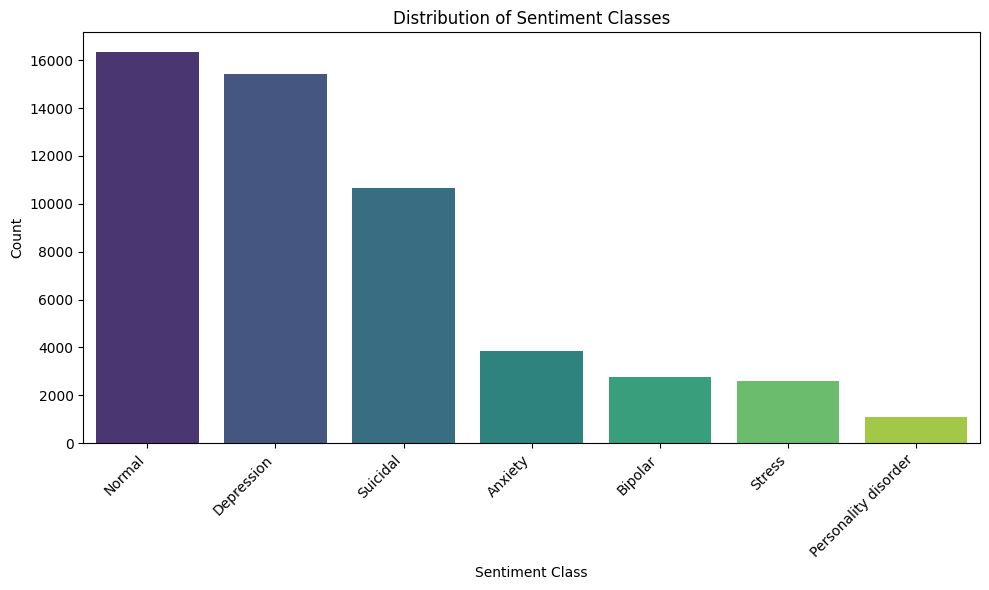

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='status', order=df['status'].value_counts().index, palette='viridis')
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Task 2 — Text Preprocessing
Perform:
lowercase conversion
punctuation removal
stopword removal
tokenization
padding
vocabulary generation

In [148]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [149]:
import nltk

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [150]:
print(df.columns)

Index(['Unnamed: 0', 'statement', 'status', 'statement_length'], dtype='object')


In [151]:
texts = df['statement'].astype(str)

In [152]:
texts = texts.str.lower()

In [153]:
texts = texts.apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

In [154]:
texts = texts.apply(word_tokenize)

Task 3 — Sequence Preparation
Convert text into numerical sequences using:
Tokenizer
word indexing
padded sequences
Explain:
Why RNN cannot directly understand raw text.




In [155]:
# Stopword removal
stop_words = set(stopwords.words('english'))

texts = texts.apply(
    lambda words: [word for word in words if word not in stop_words]
)

# Convert back to sentence
processed_texts = texts.apply(lambda words: ' '.join(words))

# Vocabulary generation
tokenizer = Tokenizer()

tokenizer.fit_on_texts(processed_texts)

word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(processed_texts)

# Padding
padded_sequences = pad_sequences(
    sequences,
    maxlen=20,
    padding='post'
)

# Output
print(processed_texts.iloc[0])
print(sequences[0])
print(padded_sequences[0])

Vocabulary Size: 74614
oh gosh
[474, 4558]
[ 474 4558    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]


In [156]:
max_sequence_len = max(len(seq) for seq in sequences)

print("Maximum Sequence Length:", max_sequence_len)

Maximum Sequence Length: 2520


Why RNN Cannot Directly Understand Raw Text

RNN models cannot process raw text because neural networks only understand numerical values, not words or sentences.

Text data must first be converted into numerical representations using tokenization and word indexing. After conversion, sequences are padded so that all inputs have equal length, allowing the RNN to process them efficiently during training.

Without sequence preparation, the RNN cannot perform mathematical operations on textual data.


Task 4 — Build Simple RNN Architecture
Students must implement:
Embedding layer
SimpleRNN layer
Dense output layer
using TensorFlow/Keras.

In [157]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# # Vocabulary size
# vocab_size = len(word_index) + 1

# # Build Simple RNN Model
# # model = Sequential()

# # # Embedding Layer
# # model.add(
# #     Embedding(
# #         input_dim=vocab_size,
# #         output_dim=64,
# #         input_length=max_sequence_len
# #     )
# # )

# model = Sequential()

# model.add(
#     Embedding(
#         input_dim=vocab_size,
#         output_dim=64,
#         input_length=max_sequence_len
#     )
# )

# model.add(SimpleRNN(64))

# model.add(
#     Dense(7, activation='softmax')
# )

# model.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()


In [158]:

# # SimpleRNN Layer
# model.add(
#     SimpleRNN(64)
# )


In [159]:

# # Dense Output Layer
# model.add(
#     Dense(1, activation='sigmoid')
# )

# # Model Summary
# model.summary()

In [161]:
# ==============================
# Task 5 — Model Training
# ==============================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import numpy as np

# Features
X = np.array(padded_sequences).astype('float32')

# Labels
encoder = LabelEncoder()

y = encoder.fit_transform(df['status'])

y = np.array(y).astype('int32')

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==============================
# Build Model
# ==============================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_sequence_len
    )
)

# RNN Layer
model.add(SimpleRNN(128))

# Output Layer for 7 Classes
model.add(
    Dense(7, activation='softmax')
)

# ==============================
# Compile Model
# ==============================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Train Model
# ==============================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


527/527 ━━━━━━━━━━━━━━━━━━━━ 77s 141ms/step - accuracy: 0.5989 - loss: 1.0417 - val_accuracy: 0.6575 - val_loss: 0.9199
Epoch 2/10
527/527 ━━━━━━━━━━━━━━━━━━━━ 85s 148ms/step - accuracy: 0.7891 - loss: 0.5891 - val_accuracy: 0.6697 - val_loss: 0.9231
Epoch 3/10
527/527 ━━━━━━━━━━━━━━━━━━━━ 77s 145ms/step - accuracy: 0.9183 - loss: 0.2504 - val_accuracy: 0.6389 - val_loss: 1.1463
Epoch 4/10
527/527 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - accuracy: 0.9653 - loss: 0.1170 - val_accuracy: 0.6383 - val_loss: 1.3174
Epoch 5/10
527/527 ━━━━━━━━━━━━━━━━━━━━ 76s 144ms/step - accuracy: 0.9818 - loss: 0.0659 - val_accuracy: 0.6368 - val_loss: 1.4554
Epoch 6/10
527/527 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - accuracy: 0.9859 - loss: 0.0515 - val_accuracy: 0.6189 - val_loss: 1.6424
Epoch 7/10
527/527 ━━━━━━━━━━━━━━━━━━━━ 83s 145ms/step - accuracy: 0.9861 - loss: 0.0480 - val_accuracy: 0.6315 - val_loss: 1.6610
Epoch 8/10
527/527 ━━━━━━━━━━━━━━━━━━━━ 84s 148ms/step - accuracy: 0.9860 - loss: 0.0484 - val

In [162]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Predictions
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

# Recall
recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

# F1 Score
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Print Results
print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)

330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.6201005978931384
Precision: 0.6230699085192978
Recall: 0.6201005978931384
F1 Score: 0.618727708552741

Confusion Matrix:
[[ 483   58   93   21    9   82    9]
 [  73  229   96   16   31   56   26]
 [ 159   85 1866  150   45   76  635]
 [ 188   24  135 2810   17   55   79]
 [  23   36   45   19   60   34   20]
 [ 101   57  114   47   23  157   37]
 [  37   30  979  144   16   23  929]]


Task 7 — Sequence Understanding
1. How RNN Remembers Previous Words

RNN (Recurrent Neural Network) processes text one word at a time while keeping information from previous words.

Example sentence:

I am feeling very anxious today

The RNN reads sequentially:

I → am → feeling → very → anxious → today

At each step, the network remembers information from earlier words and uses it to understand the current word.

For example:

after reading "feeling"
then reading "anxious"

the model understands emotional context better.

Unlike normal neural networks, RNNs have memory of previous inputs.

2. Hidden State Concept

The hidden state is the internal memory of the RNN.

It stores important information learned from previous words.

Representation:

h₀ → h₁ → h₂ → h₃ ...

Where:

h₀ = initial state
h₁ = memory after first word
h₂ = updated memory after second word

Each hidden state depends on:

current input word
previous hidden state

Formula:

h
t
	​

=f(Wx
t
	​

+Uh
t−1
	​

+b)

Where:

xₜ = current input
hₜ₋₁ = previous hidden state
hₜ = new hidden state

The hidden state acts like temporary memory for sequence learning.

3. Sequential Learning Behavior

RNN learns patterns based on word order.

Example:

I am not happy

and

I am happy

contain similar words but different meanings because of sequence order.

RNN captures this sequential dependency.

Sequential learning helps in:

sentiment analysis
emotion detection
language modeling
text generation

Because in human language, word order changes everything. “I love humans” and “humans love I” contain identical words and radically different evidence of cognitive function.

In [163]:
# ==============================
# Real-Time Prediction Function
# ==============================

def predict_emotion(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Convert back to sentence
    processed_text = ' '.join(tokens)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences(
        [processed_text]
    )

    # Padding
    padded = pad_sequences(
        sequence,
        maxlen=max_sequence_len,
        padding='post'
    )

    # Prediction
    prediction = model.predict(padded)

    predicted_class = np.argmax(prediction)

    # Decode label
    emotion = encoder.inverse_transform(
        [predicted_class]
    )

    print("Input Text:", text)

    print("Predicted Emotion:",
          emotion[0])

In [166]:
predict_emotion(
    "I cannot stop overthinking everything"
)

predict_emotion(
    "I feel peaceful and relaxed today"
)

predict_emotion(
    "Nobody cares about me anymore"
)

predict_emotion(
    "I am excited for my future"
)

predict_emotion(
    "I feel tired, hopeless, and empty"
)

predict_emotion(
    "I am scared something bad will happen"
)

predict_emotion(
    "Today was one of the best days of my life"
)

predict_emotion(
    "I feel completely alone"
)

predict_emotion(
    "I cannot sleep because my mind is racing"
)

predict_emotion(
    "I feel confident and motivated"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
Input Text: i cannot stop overthinking everything
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Input Text: i feel peaceful and relaxed today
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Input Text: nobody cares about me anymore
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
Input Text: i am excited for my future
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Input Text: i feel tired hopeless and empty
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Input Text: i am scared something bad will happen
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Input Text: today was one of the best days of my life
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
Input Text: i feel completely alone
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step
Input Text: i cannot sleep because my mind is racing
Predicted Emotion: Normal
1

In [167]:
predict_emotion(
    "Every little thing makes me nervous lately"
)

predict_emotion(
    "I do not enjoy anything anymore"
)

predict_emotion(
    "I finally feel calm after many stressful days"
)

predict_emotion(
    "I am constantly worried about my future"
)

predict_emotion(
    "I feel emotionally exhausted"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
Input Text: every little thing makes me nervous lately
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
Input Text: i do not enjoy anything anymore
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
Input Text: i finally feel calm after many stressful days
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
Input Text: i am constantly worried about my future
Predicted Emotion: Normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Input Text: i feel emotionally exhausted
Predicted Emotion: Normal
